Импорт библиотек

In [4]:
import json
import pandas as pd
import re
import spacy
from scipy.stats import ttest_ind, mannwhitneyu, shapiro
import matplotlib.pyplot as plt

!python -m spacy download ru_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 75.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Настройки и лексиконы

In [ ]:
# === Настройки ===
MY_MODEL_CSV = "my_model.csv"
MY_MODEL_JSON = "my_model.json"
BASELINE_FILES = {
    "Baseline Yandex": "yandex.json",
    "Baseline Giga": "giga.json",
    "Baseline GPT": "gpt.json"
}

OUTPUT_CSV = "comparison_results.csv"
PLOT_FILE = "model_comparison.png"

# === Загрузка spaCy ===
print("Загружаем ru_core_news_sm...")
nlp = spacy.load("ru_core_news_sm")

# === Лексиконы  ===
SUPPORTIVE_PHRASES = {
    "отлично", "молодец", "хорошо", "правильно", "верно", "здорово", "прекрасно",
    "вы на правильном пути", "почти у цели", "интересная идея", "умная мысль",
    "давайте разберёмся", "не переживайте", "это сложный момент", "всё получится",
    "не нужно расстраиваться","вы все правильно сделали"
}

SOFT_CORRECTION_PATTERNS = [
    r"хорошая попытка", r"почти верно", r"вы почти у цели",
    r"интересная идея.*но", r"почти правильно", r"неплохо, но",
    r"вы на правильном пути, но", r"давайте разберем по шагам", r"не нужно расстраиваться",r"давайте еще раз",
    r"не переживайте"

]

INTUITION_KEYWORDS = {"догадка", "кажется", "интуитивно", "похоже", "предположим", "возможно", "давайте разберем",
                      "догадка", "кажется", "интуитивно", "похоже", "предположим", "возможно",
                      "на первый взгляд", "мысленно", "представьте", "график похож на",
                      "интуитивно ясно", "можно ожидать", "близко к"}
RIGOR_KEYWORDS = {"формально", "строго", "докажем", "по определению", "следовательно", "тогда","взглянем","сначала проверим","запомните", "вспомним",
                  "cледует помнить","формально", "строго", "докажем", "по определению", "следовательно", "тогда",
    "из определения следует", "согласно теореме", "применим критерий",
    "рассмотрим математически", "точно", "аксиоматически", "определению", "определение"}





Загружаем ru_core_news_sm...


Функции для посчета метрик

In [ ]:
# === Вспомогательные функции ===
def tokenize_sentences(text):
    if not text.strip():
        return []
    doc = nlp(text)
    return [sent.text.strip() for sent in doc.sents if sent.text.strip()]

def count_questions(sentences):
    return sum(1 for s in sentences if s.endswith('?'))

def contains_soft_correction(sentence):
    sentence_lower = sentence.lower()
    return any(re.search(pattern, sentence_lower) for pattern in SOFT_CORRECTION_PATTERNS)

def contains_intuition(text):
    return any(word in text.lower() for word in INTUITION_KEYWORDS)

def contains_rigor(text):
    return any(word in text.lower() for word in RIGOR_KEYWORDS)

# === Ключевая функция: интуиция ДО строгости в ОДНОЙ реплике ===
def has_intuition_before_rigor_in_single_message(text):
    if not isinstance(text, str) or not text.strip():
        return False
    t = text.lower()
    intuition_positions = []
    rigor_positions = []
    for phrase in INTUITION_KEYWORDS:
        start = 0
        while True:
            pos = t.find(phrase, start)
            if pos == -1:
                break
            intuition_positions.append(pos)
            start = pos + 1
    for phrase in RIGOR_KEYWORDS:
        start = 0
        while True:
            pos = t.find(phrase, start)
            if pos == -1:
                break
            rigor_positions.append(pos)
            start = pos + 1
    if not intuition_positions or not rigor_positions:
        return False
    first_rigor = min(rigor_positions)
    return any(pos < first_rigor for pos in intuition_positions)

# === Проверка для одного диалога ===
def has_intuition_then_rigor_in_dialogue(dialogue):
    if not dialogue:
        return 0

    # Сначала проверяем: есть ли реплика с интуицией ДО строгости внутри неё?
    for text in dialogue:
        if has_intuition_before_rigor_in_single_message(text):
            return 1

    # Затем проверяем между репликами
    intuition_flags = [any(p in t.lower() for p in INTUITION_KEYWORDS) for t in dialogue]
    rigor_flags = [any(p in t.lower() for p in RIGOR_KEYWORDS) for t in dialogue]

    for i in range(len(dialogue)):
        if intuition_flags[i]:
            for j in range(i + 1, len(dialogue)):
                if rigor_flags[j]:
                    return 1
    return 0

def has_intuition_and_rigor(full_text):
    """
    Проверяет, что в диалоге есть интуиция ДО строгости.
    dialogue: list of messages (dicts with 'role' and 'content')
    """
    if not full_text:
        return 0

    # Находим позиции (индексы) реплик с интуицией и строгостью
    intuition_indices = []
    rigor_indices = []
    total = 0

    for idx, text in enumerate(full_text):
        t = text.lower()
        if any(phrase in t for phrase in INTUITION_KEYWORDS):
            intuition_indices.append(idx)
        if any(phrase in t for phrase in RIGOR_KEYWORDS):
            rigor_indices.append(idx)

    # Проверяем: есть ли интуиция ДО первой строгости?
        if intuition_indices and rigor_indices:
            first_rigor = min(rigor_indices)
            if any(pos < first_rigor for pos in intuition_indices):
              total+=1
        intuition_indices = []
        rigor_indices = []

    return total
    

def count_supportive_phrases(full_text):
    text_lower = full_text.lower()
    return sum(1 for phrase in SUPPORTIVE_PHRASES if phrase in text_lower)

# === Загрузка и обработка CSV (собственной модели) ===
def load_csv_model(filepath):
    df = pd.read_csv(filepath)
    # Убираем пробелы в названиях колонок
    df.columns = df.columns.str.strip()
    assistant_texts = df[df["role"] == "assistant"]["content"].fillna("").tolist()
    return assistant_texts

# === Загрузка и обработка JSON (baseline) ===
def load_json_model(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
    assistant_texts = []
    for item in data:
        conv = item.get("conversation", [])
        texts = [msg.get("content", "") for msg in conv if msg.get("role") == "assistant"]
        assistant_texts.extend(texts)
    return assistant_texts

# === Подсчёт метрик по списку текстов ===
def compute_metrics_from_texts(texts):
    if not texts:
        return None
    intuition_rigor = 0
    full_text = " ".join(texts)
    sentences = tokenize_sentences(full_text)
    n_sent = len(sentences)
    if n_sent == 0:
        return None

    n_questions = count_questions(sentences)
    n_soft = sum(1 for s in sentences if contains_soft_correction(s))
    n_supportive = count_supportive_phrases(full_text)
    intuition_rigor += has_intuition_then_rigor_in_dialogue(sentences)

    return {
        "dialogicity": n_questions / n_sent,
        "soft_correction_rate": n_soft / n_sent,
        "supportive_style": n_supportive / n_sent,
        "intuition_to_rigor_ratio": intuition_rigor / n_sent,
        "n_sentences": n_sent
    }


Запуск подсчета

✅ Моя модель загружена из CSV
✅ Baseline Yandex загружен из JSON
✅ Baseline Giga загружен из JSON
✅ Baseline GPT загружен из JSON

✅ Результаты сохранены в comparison_results.csv


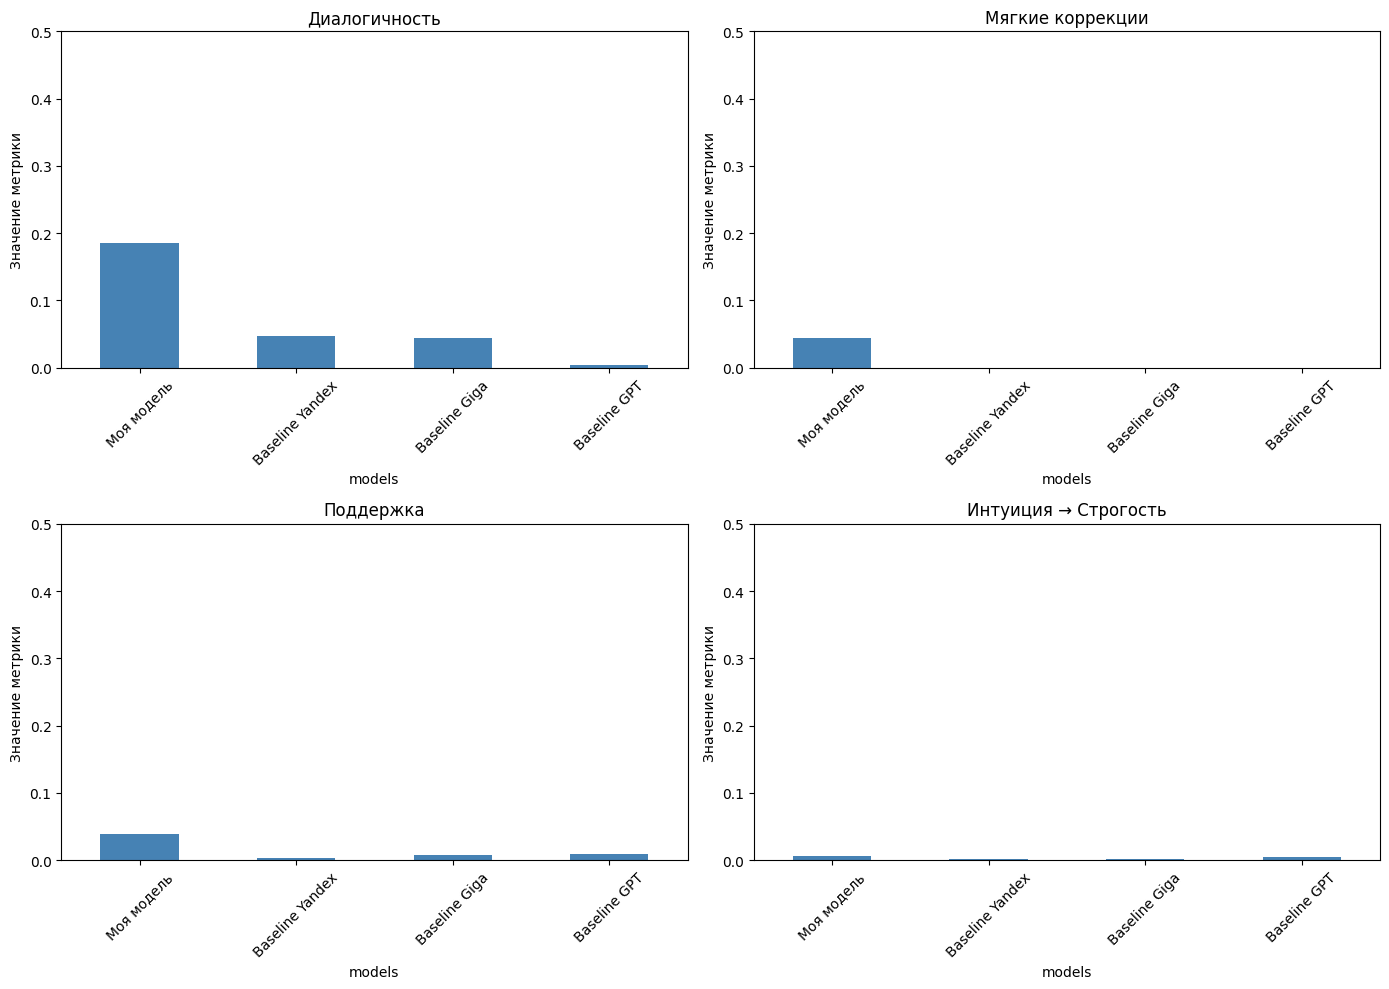


📊 Графики сохранены в model_comparison.png

🔍 Статистические тесты (Моя модель vs Baseline):
  dialogicity: Моя = 0.185, Baseline Yandex = 0.047
  soft_correction_rate: Моя = 0.045, Baseline Yandex = 0.000
  supportive_style: Моя = 0.039, Baseline Yandex = 0.004
  intuition_to_rigor_ratio: Моя = 0.006, Baseline Yandex = 0.001
  dialogicity: Моя = 0.185, Baseline Giga = 0.045
  soft_correction_rate: Моя = 0.045, Baseline Giga = 0.000
  supportive_style: Моя = 0.039, Baseline Giga = 0.008
  intuition_to_rigor_ratio: Моя = 0.006, Baseline Giga = 0.002
  dialogicity: Моя = 0.185, Baseline GPT = 0.004
  soft_correction_rate: Моя = 0.045, Baseline GPT = 0.000
  supportive_style: Моя = 0.039, Baseline GPT = 0.009
  intuition_to_rigor_ratio: Моя = 0.006, Baseline GPT = 0.004


In [ ]:
# === Основной запуск ===
if __name__ == "__main__":
    all_results = {}

    # Загружаем вашу модель из CSV
    try:
        my_texts_csv = load_csv_model(MY_MODEL_CSV)
        my_texts_json = load_json_model(MY_MODEL_JSON)
        my_texts = my_texts_csv + my_texts_json
        my_metrics = compute_metrics_from_texts(my_texts)
        if my_metrics:
            all_results["Моя модель"] = my_metrics
            print("✅ Моя модель загружена из CSV")
    except Exception as e:
        print(f"❌ Ошибка при загрузке {MY_MODEL_CSV}: {e}")

    # Загружаем baseline из JSON
    for name, path in BASELINE_FILES.items():
        try:
            texts = load_json_model(path)
            metrics = compute_metrics_from_texts(texts)
            if metrics:
                all_results[name] = metrics
                print(f"{name} загружен из JSON")
        except Exception as e:
            print(f"Ошибка при загрузке {path}: {e}")

    if not all_results:
        print("Нет данных для анализа")
        exit()

    # Сохраняем в CSV
    df = pd.DataFrame.from_dict(all_results, orient='index')
    df.index.name = 'models'
    df.to_csv(OUTPUT_CSV, encoding='utf-8')
    print(f"\n✅ Результаты сохранены в {OUTPUT_CSV}")

    # === Визуализация ===
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    metric_names = ["dialogicity", "soft_correction_rate", "supportive_style", "intuition_to_rigor_ratio"]
    titles = ["Диалогичность", "Мягкие коррекции", "Поддержка", "Интуиция → Строгость"]

    for i, (metric, title) in enumerate(zip(metric_names, titles)):
        ax = axes[i]
        df[metric].plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title(title, fontsize=12)
        ax.set_ylabel("Значение метрики")
        ax.set_ylim(0, 0.5)
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(PLOT_FILE, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nГрафики сохранены в {PLOT_FILE}")

    # === Статистические тесты (ваша модель vs каждый baseline) ===
    if "Моя модель" in all_results:
        my_data = all_results["Моя модель"]
        alpha = 0.05
        print("\n🔍 Статистические тесты (Моя модель vs Baseline):")

        for baseline in ["Baseline Yandex", "Baseline Giga", "Baseline GPT"]:
            if baseline not in all_results:
                continue

            # Для бинарной метрики используем U-тест всегда
            for metric in metric_names:
                my_val = my_data[metric]
                base_val = all_results[baseline][metric]

                # Так как у нас одно значение на модель (агрегированное),
                # для полноценного теста нужны исходные данные по каждому диалогу.
                # Но если вы хотите сравнить агрегированные значения — это не статистический тест,
                # а просто сравнение средних.
                print(f"  {metric}: Моя = {my_val:.3f}, {baseline} = {base_val:.3f}")
    else:
        print("\nСтатистические тесты невозможны: нет данных по 'Моя модель'")